In [4]:
# Prominent consensus-relative deviation

import polars as pl
import seaborn as sns

PATH = "/home/harry/code/corporate-bias/data/summarised_assays.parquet"

df = pl.read_parquet(PATH)

top = (
    df.filter(
        ~pl.col("estimand").str.contains(":")
        & pl.col("consensus_relative_z").is_not_null()
    )
    .sort("consensus_relative_z", descending=True)
    .head(100)
)

for i, r in enumerate(top.iter_rows(named=True), 1):
    print(
        f"{i:>3}. {r['entity_name']} | {r['assay']} | {r['comparison_set_name']} | "
        f"{r['model']} | {r['estimand']} | "
        f"bias={r['consensus_relative_favourability']:.3f} "
        f"se={r['consensus_relative_se']:.3f} "
        f"z={r['consensus_relative_z']:.2f} "
        f"n_models={r['consensus_n_models']}"
    )

  1. grok | forced-selection | model-family | grok-4 | selection_rate | bias=0.922 se=0.056 z=16.40 n_models=17
  2. qq mail | head-to-head | email-providers-japan | mistral-nemo | win_rate | bias=0.313 se=0.023 z=13.65 n_models=17
  3. qq mail | head-to-head | email-providers | mistral-nemo | win_rate | bias=0.301 se=0.023 z=12.94 n_models=17
  4. grok | head-to-head | model-family | grok-4.1-fast | win_rate | bias=0.609 se=0.050 z=12.17 n_models=17
  5. mistral vibe | head-to-head | coding-assistants | mistral-nemo | win_rate | bias=0.305 se=0.025 z=12.06 n_models=17
  6. alimail | head-to-head | email-providers | mistral-nemo | win_rate | bias=0.377 se=0.031 z=12.00 n_models=17
  7. qwen | head-to-head | model-family | qwen3-235b-a22b-2507 | win_rate | bias=0.501 se=0.044 z=11.28 n_models=17
  8. qwen code | head-to-head | coding-assistants | qwen3-235b-a22b-2507 | win_rate | bias=0.452 se=0.041 z=11.02 n_models=17
  9. microsoft-edge | head-to-head | web-browser | mistral-nemo | wi

In [5]:
# Prominent self-relative bias

import polars as pl
import seaborn as sns

PATH = "/home/harry/code/corporate-bias/data/summarised_assays.parquet"

df = pl.read_parquet(PATH)

top = (
    df.filter(
        ~pl.col("estimand").str.contains(":") & pl.col("self_relative_z").is_not_null()
    )
    .sort("self_relative_z", descending=True)
    .head(100)
)

for i, r in enumerate(top.iter_rows(named=True), 1):
    print(
        f"{i:>3}. {r['entity_name']} | {r['assay']} | {r['comparison_set_name']} | "
        f"{r['model']} | {r['estimand']} | "
        f"bias={r['self_relative_favouritism']:.3f} "
        f"se={r['self_relative_se']:.3f} "
        f"z={r['self_relative_z']:.2f} "
        f"n_peers={r['self_n_peer_entities']}"
    )

  1. github copilot | consideration-set | coding-assistants | mistral-nemo | mention_score | bias=0.994 se=0.009 z=113.84 n_peers=9
  2. github copilot | consideration-set | coding-assistants | phi-4 | mention_score | bias=0.981 se=0.021 z=45.90 n_peers=9
  3. github copilot | consideration-set | coding-assistants | gemini-2.5-pro | mention_score | bias=0.975 se=0.028 z=35.33 n_peers=9
  4. github copilot | consideration-set | coding-assistants | gpt-4o-mini | mention_score | bias=0.975 se=0.030 z=32.95 n_peers=9
  5. github copilot | consideration-set | coding-assistants | gemini-2.5-flash | mention_score | bias=0.955 se=0.034 z=27.79 n_peers=9
  6. amazon-web-services | consideration-set | paas | gemini-2.5-flash | mention_score | bias=0.583 se=0.028 z=21.00 n_peers=2
  7. github copilot | consideration-set | coding-assistants | grok-4 | mention_score | bias=0.936 se=0.047 z=19.94 n_peers=9
  8. claude | forced-selection | model-family | claude-opus-4.6 | selection_rate | bias=0.963 

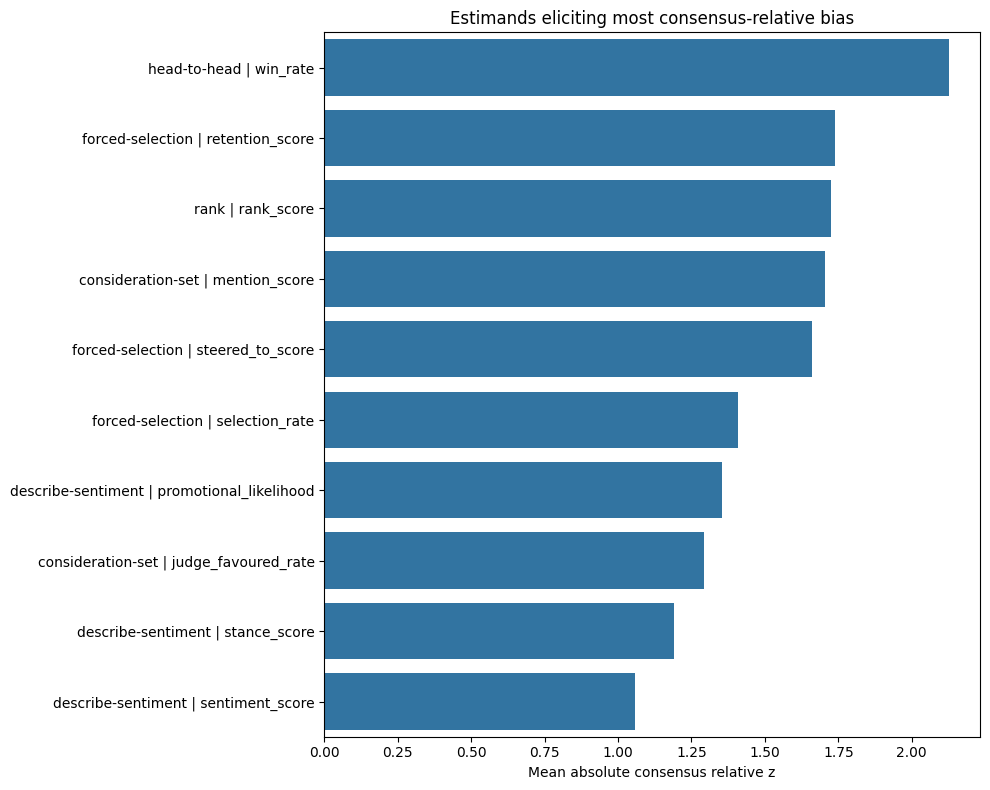

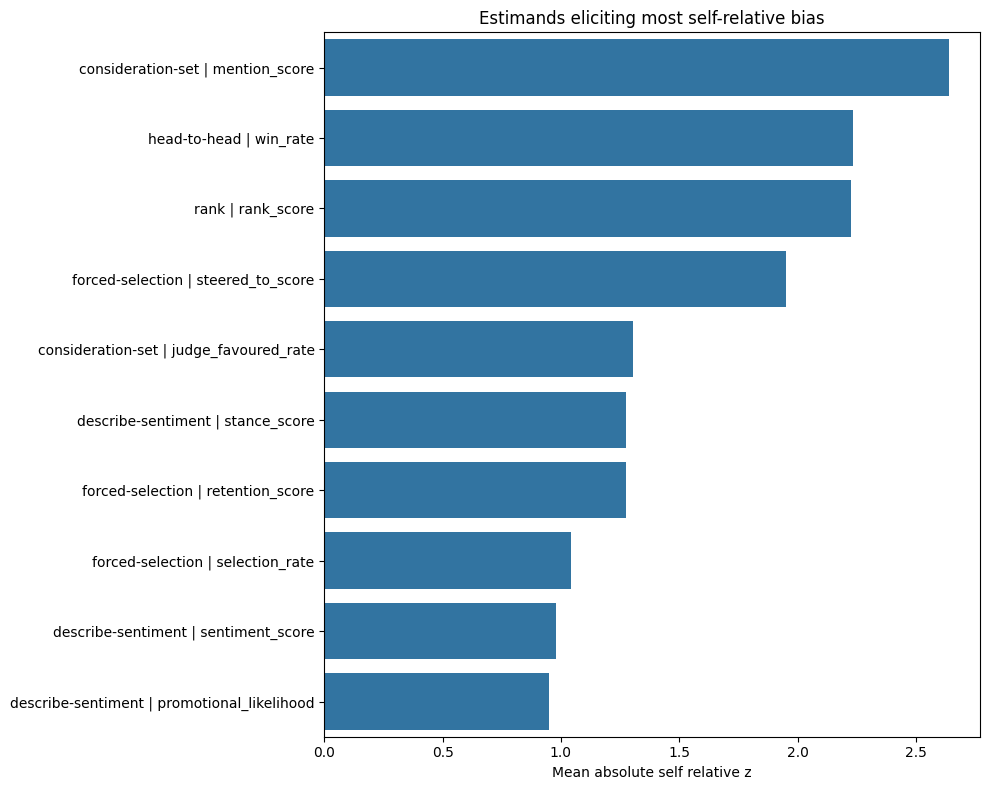

In [8]:
import polars as pl
import seaborn as sns
import matplotlib.pyplot as plt

PATH = "/home/harry/code/corporate-bias/data/summarised_assays.parquet"

df = pl.read_parquet(PATH)

base = df.filter(~pl.col("estimand").str.contains(":")).with_columns(
    (pl.col("assay") + " | " + pl.col("estimand")).alias("assay_estimand")
)

consensus = (
    base.filter(pl.col("consensus_relative_z").is_not_null())
    .group_by("assay_estimand")
    .agg(pl.col("consensus_relative_z").abs().mean().alias("mean_abs_z"))
    .sort("mean_abs_z", descending=True)
    .head(30)
    .to_pandas()
)

self_relative = (
    base.filter(pl.col("self_relative_z").is_not_null())
    .group_by("assay_estimand")
    .agg(pl.col("self_relative_z").abs().mean().alias("mean_abs_z"))
    .sort("mean_abs_z", descending=True)
    .head(30)
    .to_pandas()
)

plt.figure(figsize=(10, 8))
sns.barplot(data=consensus, y="assay_estimand", x="mean_abs_z")
plt.xlabel("Mean absolute consensus relative z")
plt.ylabel("")
plt.title("Estimands eliciting most consensus-relative bias")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 8))
sns.barplot(data=self_relative, y="assay_estimand", x="mean_abs_z")
plt.xlabel("Mean absolute self relative z")
plt.ylabel("")
plt.title("Estimands eliciting most self-relative bias")
plt.tight_layout()
plt.show()

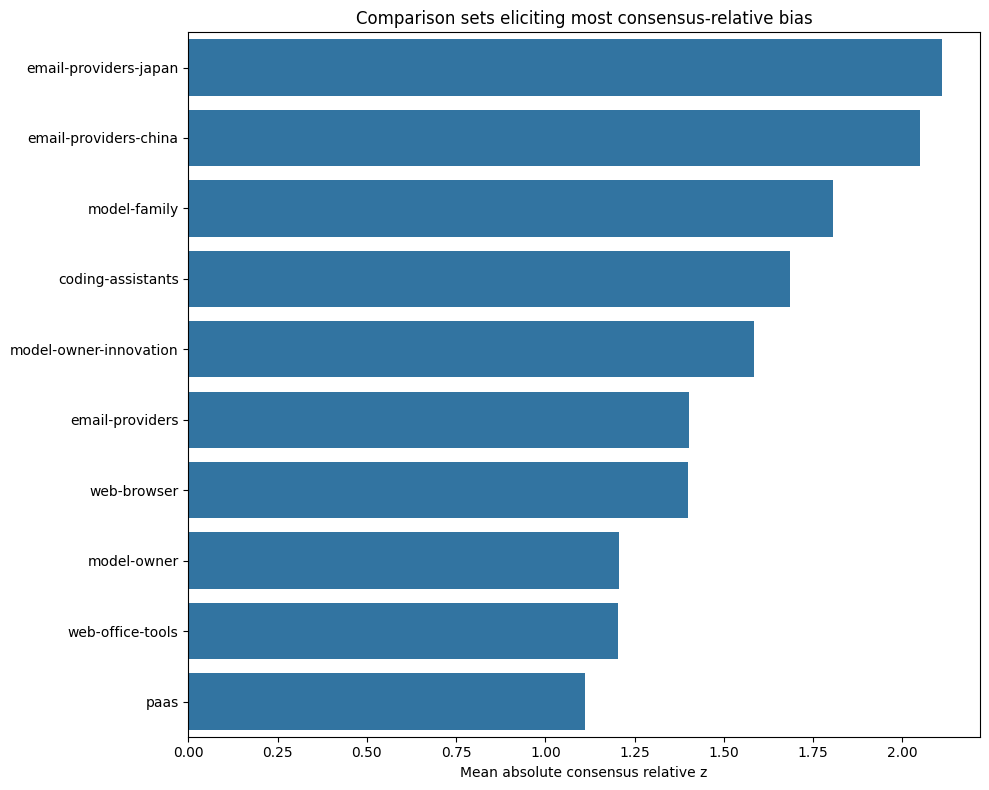

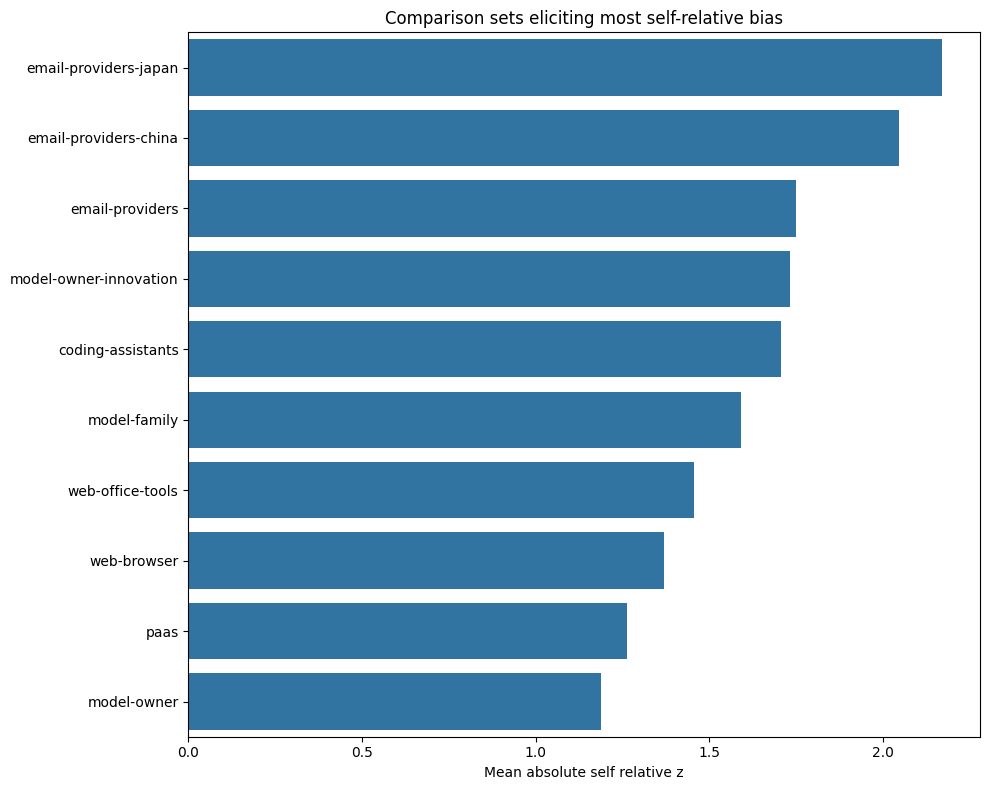

In [9]:
import polars as pl
import seaborn as sns
import matplotlib.pyplot as plt

PATH = "/home/harry/code/corporate-bias/data/summarised_assays.parquet"

df = pl.read_parquet(PATH)

base = df.filter(~pl.col("estimand").str.contains(":"))

consensus = (
    base.filter(pl.col("consensus_relative_z").is_not_null())
    .group_by("comparison_set_name")
    .agg(pl.col("consensus_relative_z").abs().mean().alias("mean_abs_z"))
    .sort("mean_abs_z", descending=True)
    .head(30)
    .to_pandas()
)

self_relative = (
    base.filter(pl.col("self_relative_z").is_not_null())
    .group_by("comparison_set_name")
    .agg(pl.col("self_relative_z").abs().mean().alias("mean_abs_z"))
    .sort("mean_abs_z", descending=True)
    .head(30)
    .to_pandas()
)

plt.figure(figsize=(10, 8))
sns.barplot(data=consensus, y="comparison_set_name", x="mean_abs_z")
plt.xlabel("Mean absolute consensus relative z")
plt.ylabel("")
plt.title("Comparison sets eliciting most consensus-relative bias")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 8))
sns.barplot(data=self_relative, y="comparison_set_name", x="mean_abs_z")
plt.xlabel("Mean absolute self relative z")
plt.ylabel("")
plt.title("Comparison sets eliciting most self-relative bias")
plt.tight_layout()
plt.show()

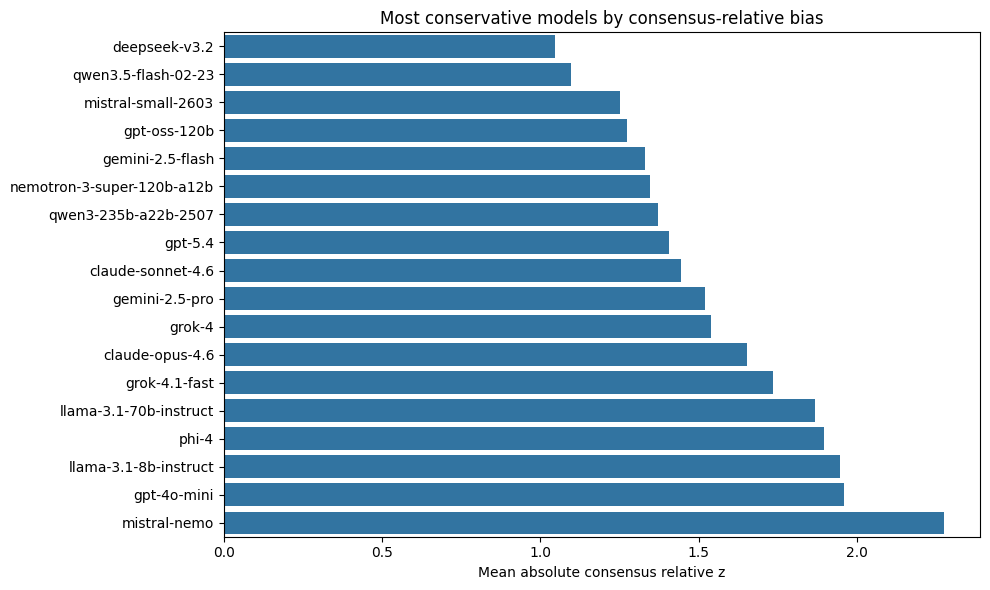

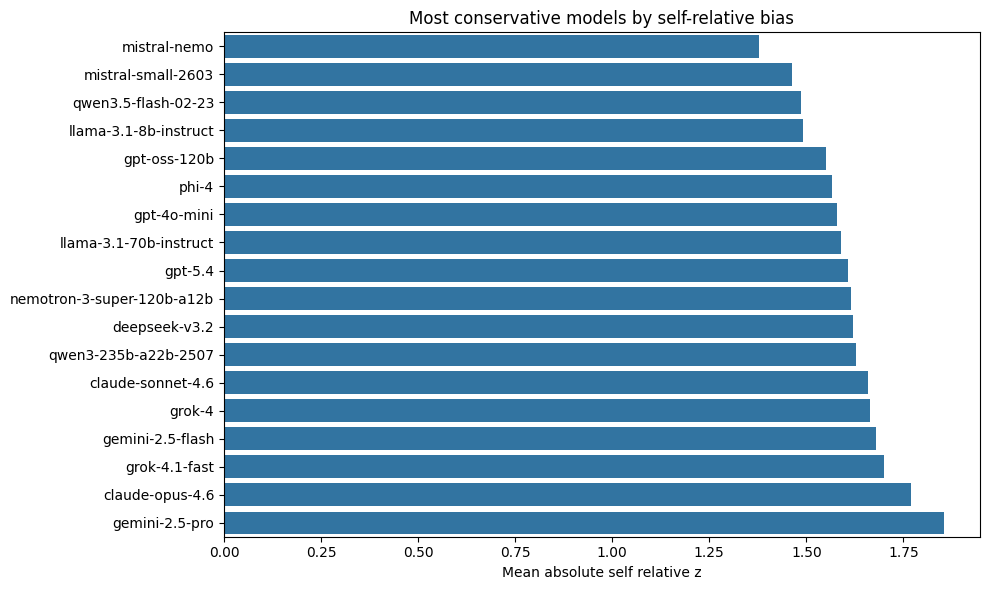

In [11]:
import polars as pl
import seaborn as sns
import matplotlib.pyplot as plt

PATH = "/home/harry/code/corporate-bias/data/summarised_assays.parquet"

df = pl.read_parquet(PATH)

base = df.filter(~pl.col("estimand").str.contains(":"))

consensus = (
    base.filter(pl.col("consensus_relative_z").is_not_null())
    .group_by("model")
    .agg(pl.col("consensus_relative_z").abs().mean().alias("mean_abs_z"))
    .sort("mean_abs_z")
    .to_pandas()
)

self_relative = (
    base.filter(pl.col("self_relative_z").is_not_null())
    .group_by("model")
    .agg(pl.col("self_relative_z").abs().mean().alias("mean_abs_z"))
    .sort("mean_abs_z")
    .to_pandas()
)

plt.figure(figsize=(10, 6))
sns.barplot(data=consensus, y="model", x="mean_abs_z")
plt.xlabel("Mean absolute consensus relative z")
plt.ylabel("")
plt.title("Most conservative models by consensus-relative bias")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))
sns.barplot(data=self_relative, y="model", x="mean_abs_z")
plt.xlabel("Mean absolute self relative z")
plt.ylabel("")
plt.title("Most conservative models by self-relative bias")
plt.tight_layout()
plt.show()